In [31]:
import JLD
import PyCallJLD

using PyPlot
using RDatasets: dataset
using ScikitLearn
using ScikitLearn.CrossValidation: cross_val_score
using ScikitLearn.GridSearch: GridSearchCV
using Statistics

@sk_import linear_model: LogisticRegression

┌ Info: Precompiling JLD [4138dd39-2aa7-5051-a626-17a0bb65d9c8]
└ @ Base loading.jl:1260
  likely near /Users/dsatterthwaite/.julia/packages/JLD/uVJmd/src/JLD.jl:5
  likely near /Users/dsatterthwaite/.julia/packages/JLD/uVJmd/src/JLD00.jl:7
┌ Info: Precompiling PyCallJLD [de320387-30cd-5f83-91a8-a6e0ae8b8444]
└ @ Base loading.jl:1260


PyObject <class 'sklearn.linear_model._logistic.LogisticRegression'>

In [2]:
iris = dataset("datasets", "iris")
first(iris, 5)

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
,Float64,Float64,Float64,Float64,Cat…
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa


In [3]:
typeof(iris)

DataFrames.DataFrame

In [4]:
X = convert(
    Array, 
    iris[!, [:SepalLength, :SepalWidth, :PetalLength, :PetalWidth]])
typeof(X)

Array{Float64,2}

In [5]:
y = convert(Array, iris[!, :Species])

150-element Array{String,1}:
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 ⋮
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"

### Regression Example

In [32]:
mod = LogisticRegression(fit_intercept=true, max_iter=200)
fit!(mod, X, y)

PyObject LogisticRegression(max_iter=200)

In [33]:
acc = score(mod, X, y)
println("Accuracy: $acc")

Accuracy: 0.9733333333333334


### Cross-Validation
Return values are the accuracy of each of the (5) folds

In [34]:
cross_val_score(LogisticRegression(max_iter=130), X, y; cv=5)

5-element Array{Float64,1}:
 0.9666666666666667
 1.0
 0.9333333333333333
 0.9666666666666667
 1.0

## Hyperparameter Tuning

In [35]:
grid = GridSearchCV(LogisticRegression(max_iter=200), 
                    Dict(:C => 0.1:0.1:2.0))
fit!(grid, X, y)

GridSearchCV
  estimator: PyCall.PyObject
  param_grid: Dict{Symbol,StepRangeLen{Float64,Base.TwicePrecision{Float64},Base.TwicePrecision{Float64}}}
  scoring: Nothing nothing
  loss_func: Nothing nothing
  score_func: Nothing nothing
  fit_params: Dict{Any,Any}
  n_jobs: Int64 1
  iid: Bool true
  refit: Bool true
  cv: Nothing nothing
  verbose: Int64 0
  error_score: String "raise"
  scorer_: score (function of type typeof(score))
  best_params_: Dict{Symbol,Any}
  best_score_: Float64 0.9733333333333334
  grid_scores_: Array{ScikitLearn.Skcore.CVScoreTuple}((20,))
  best_estimator_: PyCall.PyObject


In [36]:
println("Best Parameters: C = $(grid.best_params_[:C])")

Best Parameters: C = 0.6


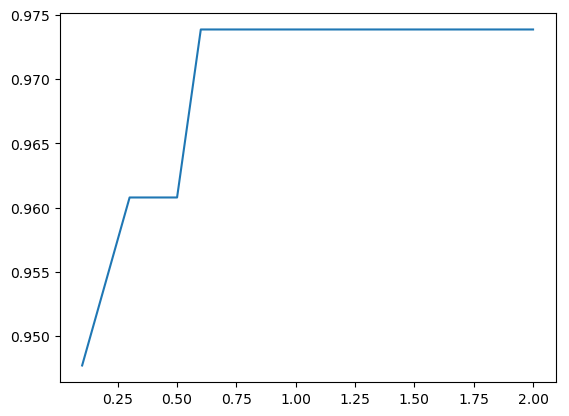

1-element Array{PyCall.PyObject,1}:
 PyObject <matplotlib.lines.Line2D object at 0x7fc2b2918b38>

In [37]:
plot([cv_res.parameters[:C] for cv_res in grid.grid_scores_],
     [mean(cv_res.cv_validation_scores) for cv_res in grid.grid_scores_])

### Saving

In [38]:
JLD.save("iris_logistic.jld", "model", mod)

  likely near /Users/dsatterthwaite/.julia/packages/IJulia/DrVMH/src/kernel.jl:52


In [40]:
mod = JLD.load("iris_logistic.jld", "model")

PyObject LogisticRegression(max_iter=200)

In [42]:
mod.predict([[4.6, 3.5, 1.5, 0.2]])

PyObject array(['setosa'], dtype='<U10')